In [8]:
!pip install scikit-learn matplotlib seaborn pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df['target'] = iris.target

print(df.head())

print(df.describe().round(2))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  target  
0  setosa       0  
1  setosa       0  
2  setosa       0  
3  setosa       0  
4  setosa       0  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%            

In [4]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

   MODELO 1: REGRESIÓN LOGÍSTICA

🎯 Accuracy: 0.9333 (93.33%)

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


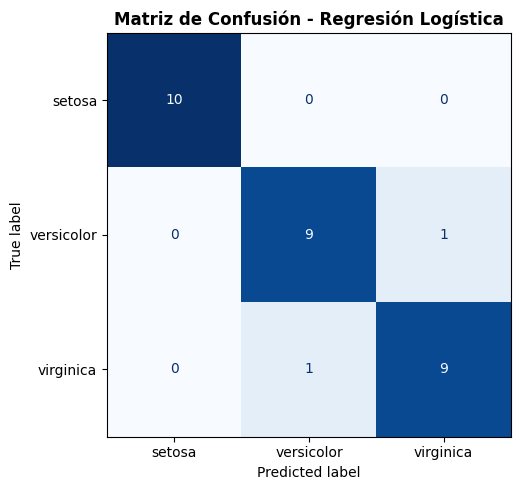


 ¿Cómo clasifica la Regresión Logística?
   Aprende fronteras de decisión lineales mediante la función
   sigmoide. Para cada clase calcula una probabilidad P(y=k|X)
   usando pesos aprendidos durante el entrenamiento.
   Asigna la clase con mayor probabilidad posterior.


In [5]:
print("   MODELO 1: REGRESIÓN LOGÍSTICA")

lr_model = LogisticRegression(
    max_iter=200,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr     = accuracy_score(y_test, y_pred_lr)

print(f"\n🎯 Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_lr,
                             target_names=iris.target_names))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=iris.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión - Regresión Logística', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n ¿Cómo clasifica la Regresión Logística?")
print("   Aprende fronteras de decisión lineales mediante la función")
print("   sigmoide. Para cada clase calcula una probabilidad P(y=k|X)")
print("   usando pesos aprendidos durante el entrenamiento.")
print("   Asigna la clase con mayor probabilidad posterior.")

   MODELO 2: ÁRBOL DE DECISIÓN

🎯 Accuracy: 0.9333 (93.33%)

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



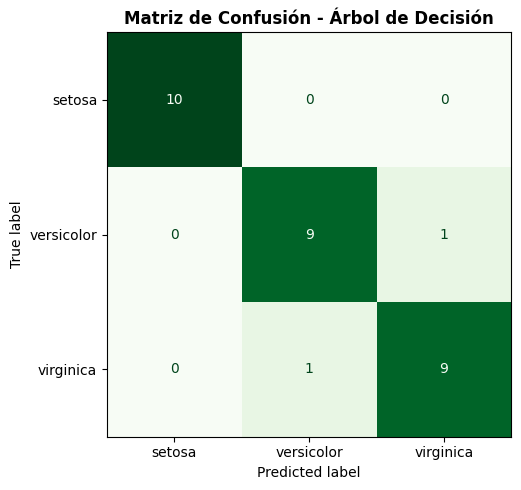

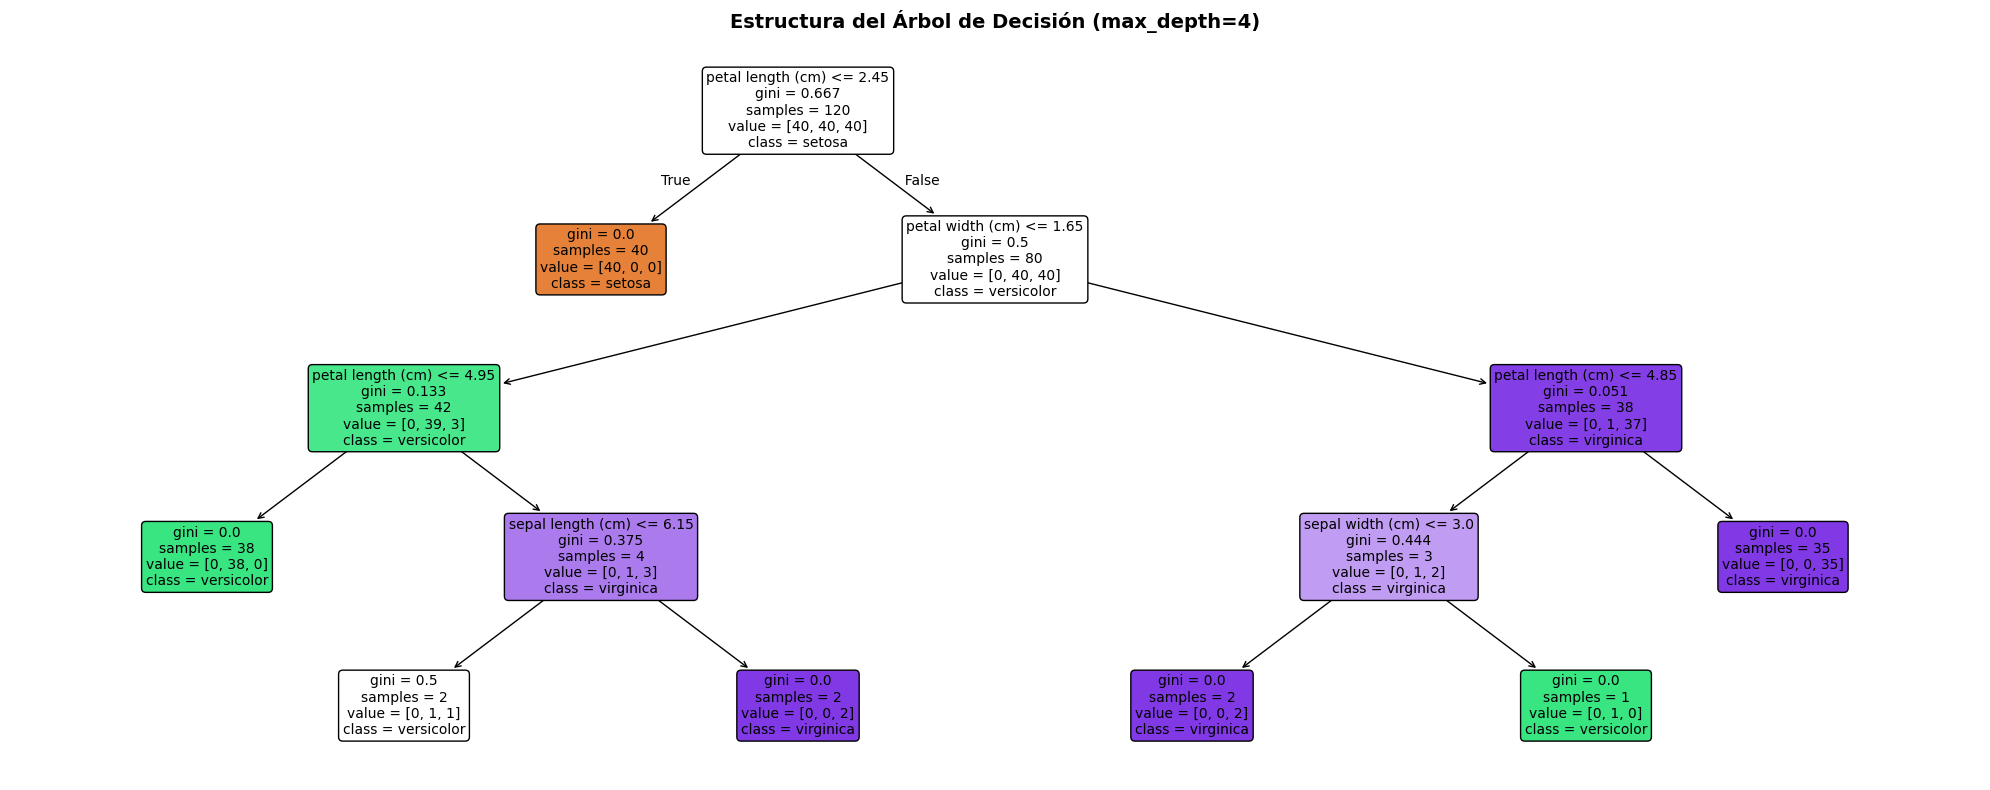


💡 ¿Cómo clasifica el Árbol de Decisión?
   Divide el espacio de características con umbrales en cada nodo.
   Cada split maximiza la pureza (Gini o Entropía) de los nodos hijos.
   La clasificación sigue el camino de regla-en-regla hasta una hoja.

📊 Importancia de características:
petal length (cm)    0.5656
petal width (cm)     0.4112
sepal width (cm)     0.0169
sepal length (cm)    0.0063
dtype: float64


In [6]:
# --- CELDA 6: Modelo 2 - Árbol de Decisión ---

print("=" * 55)
print("   MODELO 2: ÁRBOL DE DECISIÓN")
print("=" * 55)

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    criterion='gini'
)
dt_model.fit(X_train, y_train)   # sin escalar: árboles no lo necesitan

y_pred_dt = dt_model.predict(X_test)
acc_dt     = accuracy_score(y_test, y_pred_dt)

print(f"\n🎯 Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_dt,
                             target_names=iris.target_names))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                display_labels=iris.target_names)
disp2.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusión - Árbol de Decisión', fontweight='bold')
plt.tight_layout()
plt.show()

# Visualizar el árbol
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Estructura del Árbol de Decisión (max_depth=4)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 ¿Cómo clasifica el Árbol de Decisión?")
print("   Divide el espacio de características con umbrales en cada nodo.")
print("   Cada split maximiza la pureza (Gini o Entropía) de los nodos hijos.")
print("   La clasificación sigue el camino de regla-en-regla hasta una hoja.")

# Importancia de características
importances = pd.Series(dt_model.feature_importances_,
                         index=iris.feature_names).sort_values(ascending=False)
print(f"\n📊 Importancia de características:\n{importances.round(4)}")

       COMPARACIÓN: REGRESIÓN LOGÍSTICA vs ÁRBOL
             Modelo  Accuracy  Errores             Frontera     Escalado      Interpretabilidad
Regresión Logística    0.9333        1               Lineal    Requerido   Media (coeficientes)
  Árbol de Decisión    0.9333        1 No lineal (umbrales) No requerido Alta (reglas visibles)


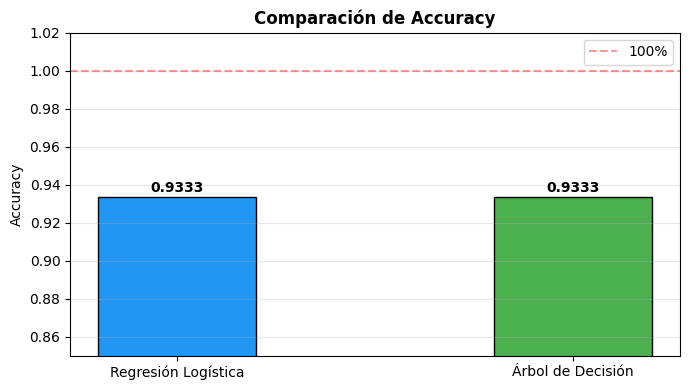

In [7]:
# --- CELDA 7: Comparación final de ambos modelos ---

print("=" * 60)
print("       COMPARACIÓN: REGRESIÓN LOGÍSTICA vs ÁRBOL")
print("=" * 60)

resultados = pd.DataFrame({
    'Modelo'   : ['Regresión Logística', 'Árbol de Decisión'],
    'Accuracy' : [round(acc_lr, 4), round(acc_dt, 4)],
    'Errores'  : [int((1-acc_lr)*len(y_test)), int((1-acc_dt)*len(y_test))],
    'Frontera' : ['Lineal', 'No lineal (umbrales)'],
    'Escalado' : ['Requerido', 'No requerido'],
    'Interpretabilidad': ['Media (coeficientes)', 'Alta (reglas visibles)']
})

print(resultados.to_string(index=False))

# Gráfico comparativo de accuracy
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Regresión Logística', 'Árbol de Decisión'],
              [acc_lr, acc_dt],
              color=['#2196F3', '#4CAF50'],
              width=0.4, edgecolor='black')
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Comparación de Accuracy', fontweight='bold')
for bar, val in zip(bars, [acc_lr, acc_dt]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.4, label='100%')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()